TLDR; this notebook is for generating EDC curves and pAUC values. That includes generating mated pairs, extracting embeddings, generating comparison scores and then doing the qctual analysis. Everything must be run the first time, but once that is done it is possilbe to load -pkl files to not rerun some steps, like building the embedding table and computing comparison scores. \
This setup takes test-prediction csv as input in EXPERIMENTS. Exclusing LOSO-youtube because I cannot make mated pairs. 
If anyone actually reads this - note that the "custom" dataset is actually the "gjovik" dataset

## environment variables & FIQAT sanity check

In [101]:
import os
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import fiqat
import fiqat.main_api as fmain
import fiqat.edc as fedc
from fiqat.config import load_config_data, get_config_path_default

In [102]:
print("FIQAT imported from:", fiqat.__file__)
print("Default FIQAT config path:", get_config_path_default())


#toml_template=Path("/margrethe/fiqat/fiqat/fiqat_example.toml")
#toml_path=Path("/margrethe/fiqat/fiqat/local/fiqat.toml")

# Load config (uses FIQAT_CONFIG env var if set, otherwise default path)
cfg = load_config_data()
print("Loaded config keys:", list(cfg.keys())[:10])

# Inspect signatures because minor version differences are possible
#print("extract_face_recognition_features:", inspect.signature(fmain.extract_face_recognition_features))
#print("compute_comparison_scores:", inspect.signature(fmain.compute_comparison_scores))
#print("compute_edc:", inspect.signature(fedc.compute_edc))
#print("compute_edc_pauc:", inspect.signature(fedc.compute_edc_pauc))

FIQAT imported from: /margrethe/fiqat/fiqat/src/fiqat/__init__.py
Default FIQAT config path: /margrethe/fiqat/fiqat/local/fiqat.toml
Loaded config keys: ['models', 'tqdm', 'insightface', 'dlib', 'crfiqa', 'faceqnet', 'retinaface', 'mtcnn', 'arcface', 'magface']


## define experiments
these are the models from which to plot EDC and pAUC

In [143]:
# these are the original experimental protocols (except loso_youtube 'cus mated pair issues)
EXPERIMENTS_ = {
    "protocol1": {
        "vit_csv": "/margrethe/code/models/ViT_PROTOCOLS_reporting/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__p1_rerun4/test_predictions.csv",
        "ofiq_csv": "/margrethe/code/models/OFIQ_reporting/full_prot1_OFIQ_test_predictions.csv",    
        "densenet_csv": None,                                  
    },
    "protocol2": {
        "vit_csv": "/margrethe/code/models/ViT_PROTOCOLS_reporting/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__p2/test_predictions.csv",
        "ofiq_csv": "/margrethe/code/models/OFIQ_reporting/full_prot2_OFIQ_test_predictions.csv",
        "densenet_csv": None,
    },
    "loso_custom": {
        "vit_csv": "/margrethe/code/models/ViT_LOSO_reporting/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__loso_custom_rerun2/test_predictions.csv",
        "ofiq_csv": "/margrethe/code/models/OFIQ_reporting/full_custom_OFIQ_test_predictions.csv",
        "densenet_csv": None,
    },
    "loso_edamb": {
        "vit_csv": "/margrethe/code/models/ViT_LOSO_reporting/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__loso_edamb_rerun3/test_predictions.csv",
        "ofiq_csv": "/margrethe/code/models/OFIQ_reporting/full_EDAMB_OFIQ_test_predictions.csv",
        "densenet_csv": None,
    },
}

#These are test-data where the 4 models from model C are tested on the ENTIRE EDAMB dataset. Because I think that's what the others have done...
EXPERIMENTS={
    "protocol1": {
        "vit_csv": "/margrethe/code/models/00_FINAL_REPORTING/EDAMB/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__p1_rerun4/predictions.csv",
    },
    "protocol2": {
        "vit_csv": "/margrethe/code/models/00_FINAL_REPORTING/EDAMB/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__p2/predictions.csv",
    },
    #"loso_custom": { # loso custom is literally trained on the WHOLE EDMAB. this one is not compatible
    #    "vit_csv": "/margrethe/code/models/00_FINAL_REPORTING/EDAMB/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__loso_custom_rerun2/predictions.csv",
    #},
    "loso_edamb": {
        "vit_csv": "/margrethe/code/models/ViT_LOSO_reporting/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__loso_edamb_rerun3/test_predictions.csv", #keeping this one au natural since its edamb
    },
    "ofiq_edamb": {
        "ofiq_csv": "/margrethe/code/models/OFIQ_reporting/full_EDAMB_OFIQ_test_predictions.csv",
    },
}

"""
# these are additional things I have done in order to fill out a reporting table for Pauc, MAE and RMSE. 
# so these are loso_edamb tested on p1 and p2, and p1/p2 tested on custom
EXPERIMENTS={
    "custom_from_p1": {
        "vit_csv": "/margrethe/code/models//00_FINAL_REPORTING/protocol1_test_on_custom/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__p1_rerun4/predictions.csv",
        "vit_csv": "/margrethe/code/models/00_FINAL_REPORTING/protocol2_test_on_custom/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__p2/predictions.csv",
    },
   # "custom_from_p2": {
   #     "vit_csv": "/margrethe/code/models/00_FINAL_REPORTING/protocol2_test_on_custom/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__p2/predictions.csv",
   # },
    "protocol1_from_loso_edamb": {
        "vit_csv": "/margrethe/code/models/00_FINAL_REPORTING/loso-edamb_test_on_procotol1/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__loso_edamb_rerun3/predictions.csv", 
    },
    "protocol2_from_loso_edamb": {
        "vit_csv": "/margrethe/code/models/00_FINAL_REPORTING/loso-edamb_test_on_procotol2/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__loso_edamb_rerun3/predictions.csv",
    },
}
"""  

'\n# these are additional things I have done in order to fill out a reporting table for Pauc, MAE and RMSE. \n# so these are loso_edamb tested on p1 and p2, and p1/p2 tested on custom\nEXPERIMENTS={\n    "custom_from_p1": {\n        "vit_csv": "/margrethe/code/models//00_FINAL_REPORTING/protocol1_test_on_custom/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__p1_rerun4/predictions.csv",\n        "vit_csv": "/margrethe/code/models/00_FINAL_REPORTING/protocol2_test_on_custom/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__p2/predictions.csv",\n    },\n   # "custom_from_p2": {\n   #     "vit_csv": "/margrethe/code/models/00_FINAL_REPORTING/protocol2_test_on_custom/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__p2/predictions.csv",\n   # },\n    "protocol1_from_loso_edamb": {\n        "vit_csv": "/margrethe/code/models/00_FINAL_REPORTING/loso-edamb_test_on_procotol1/FT_small_dinov2_smoothl1_bs10_lr8e6_wd5e4_do00_noaug__loso_edamb_rerun3/predictions.csv", \n    },\n    "pr

## helper functios

In [104]:
def choose_subject_id(df: pd.DataFrame) -> pd.Series:
    sid = pd.Series([None] * len(df), index=df.index, dtype="object")

    if "edamb_subject_id" in df.columns:
        sid = sid.where(df["edamb_subject_id"].isna(), df["edamb_subject_id"].astype(str))

    if "custom_subject_id" in df.columns:
        sid = sid.where(df["custom_subject_id"].isna(), df["custom_subject_id"].astype(str))

    return sid


def base_sample_table_from_predictions(pred_csv: str, pred_score: str, new_quality_name: str) -> pd.DataFrame:
    df = pd.read_csv(pred_csv)

    out = pd.DataFrame({
        "key": df["key"],
        "source": df["source"],
        "image_path": df["minimal_aligned_path"],   # your chosen image input for embeddings
        "subject_id": choose_subject_id(df),
        new_quality_name: df[pred_score].astype(float),
    })

    # Keep only rows where identity is known and image path exists
    out = out[out["subject_id"].notna()].copy()
    out = out[out["image_path"].notna()].copy()

    # Remove duplicates by key if any
    out = out.drop_duplicates(subset=["key"]).reset_index(drop=True)
    return out

## merge info from different models in to one sample table per experiment
one experiment can be "protocol1", or LOSO-custom

In [7]:
def load_experiment_sample_table(exp_cfg: dict) -> pd.DataFrame:
    # ViT from the EXPERIMENTS variable
    sample_df = base_sample_table_from_predictions(
        exp_cfg["vit_csv"],
        pred_score="pred01",         # choosing one column with prediction values
        new_quality_name="pred_vit"
    )
    sample_df["pred_vit"] = sample_df["pred_vit"] * 100.0
    
    # OFIQ sharpness from the EXPERIMENTS variable
    if exp_cfg.get("ofiq_csv"):
        ofiq_df = pd.read_csv(exp_cfg["ofiq_csv"])
        ofiq_keep = ofiq_df[["key", "ofiq_sharpness"]].rename(columns={"ofiq_sharpness": "pred_ofiq"})
        sample_df = sample_df.merge(ofiq_keep, on="key", how="left")

#this isn't going to be implemented. 
    """
    # DenseNet?
    if exp_cfg.get("densenet_csv"):
        dns_df = pd.read_csv(exp_cfg["densenet_csv"])
        ## cahgne column names when this is done
        dns_keep = dns_df[["key", "pred01"]].rename(columns={"pred01": "pred_densenet"})
        sample_df = sample_df.merge(dns_keep, on="key", how="left")
    """
    return sample_df

#### Created for building curves for models ALL tested on whole EDAMB

In [105]:
# ============================================================
# Build unified sample_df with ALL quality scores (EDAMB)
# ============================================================

def load_edamb_all_models(EXPERIMENTS):
    sample_df = None

    for exp_name, cfg in EXPERIMENTS.items():
        if "vit_csv" in cfg:
            df = pd.read_csv(cfg["vit_csv"])
            keep = df[["key", "pred01"]].rename(
                columns={"pred01": f"pred_{exp_name}"}
            )
            keep[f"pred_{exp_name}"] *= 100.0  # keep same scaling as before

        elif "ofiq_csv" in cfg:
            df = pd.read_csv(cfg["ofiq_csv"])
            keep = df[["key", "ofiq_sharpness"]].rename(
                columns={"ofiq_sharpness": "pred_ofiq"}
            )

        else:
            continue

        if sample_df is None:
            sample_df = keep
        else:
            sample_df = sample_df.merge(keep, on="key", how="inner")

    return sample_df


## Experiment switch here! E.g. the type of model "setup" to run; loso_Edamb/loso_custom/protocol1/protocol2
This affects the images loaded/run in the feature extraction - or changes the variable name for when you load saved .pkl files. This logic can be clanged later though

In [115]:
exp_name = "loso_edamb" #protocol1, protocol2, loso_custom, loso_edamb

from pathlib import Path
OUT_DIR = Path("/margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# original setup
sample_df = load_experiment_sample_table(EXPERIMENTS[exp_name])

# models all tested on EDAMB setup
#sample_df = load_edamb_all_models(EXPERIMENTS)

display(sample_df.head())
#sample_df.to_csv("/margrethe/fiqat/fiqat/local/sample_table.csv", index=False)
print(len(sample_df))

,key,source,image_path,subject_id,pred_vit,pred_ofiq
0,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB,/margrethe/preprocessed_images/minimal_preproc...,724086,30.291727,29.0
1,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB,/margrethe/preprocessed_images/minimal_preproc...,724086,7.052320,0.0
2,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB,/margrethe/preprocessed_images/minimal_preproc...,724086,10.846164,1.0
3,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB,/margrethe/preprocessed_images/minimal_preproc...,724086,9.359302,0.0
4,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB,/margrethe/preprocessed_images/minimal_preproc...,724086,11.942796,0.0


1154


# Embeddings: FIQAT ArcFace extraction

In [7]:
print(inspect.signature(fmain.extract_face_recognition_features))

(method_id: Union[pathlib.PurePath, str], images: Union[pathlib.Path, numpy.ndarray, PIL.Image.Image, Iterable[Union[pathlib.Path, numpy.ndarray, PIL.Image.Image]]], tqdm_config: Union[bool, tuple, list, dict] = True, **kwargs) -> Union[numpy.ndarray, Iterable[numpy.ndarray]]


#### Extract face recognition features

In [293]:
# Candidate image list
from pathlib import Path
image_paths = [Path(p) for p in sample_df["image_path"]]

#NB: if the lsit() is not added - it does not compute anything. must use list()
features = list(
    fmain.extract_face_recognition_features(
        "fr/arcface",
        image_paths,
        batch_size=8,
        device="cpu",
        #tqdm_config=False,
    )
)

fiqat.extract_face_recognition_features: fr/arcface:   0%|                                                       | 0/1154 [00:00<?, ?it/s][20:19:43] ../src/nnvm/legacy_json_util.cc:208: Loading symbol saved by previous version v1.2.0. Attempting to upgrade...
[20:19:43] ../src/nnvm/legacy_json_util.cc:216: Symbol successfully upgraded!
[20:19:43] ../src/executor/graph_executor.cc:1991: Subgraph backend MKLDNN is activated.
fiqat.extract_face_recognition_features: fr/arcface: 100%|████████████████████████████████████████████| 1154/1154 [00:48<00:00, 23.60it/s]


#### build embedding table
For ArcFace, each image returns a vector with many numbers — typically: 512 floating‑point values per image

In [306]:

# Inspect first:
print(type(features))
if hasattr(features, "__len__"):
    print("n_features:", len(features))

# this only has to be run once - look for loading the pkl file for the given model setup (loso/protocol) 
embedding_df = pd.DataFrame({
    "key": sample_df["key"].tolist(),
    "subject_id": sample_df["subject_id"].tolist(),
    "image_path": sample_df["image_path"].tolist(),
    "embedding": list(features),
})

embedding_df.head()

<class 'list'>
n_features: 1154


,key,subject_id,image_path,embedding
0,EDAMB/data-collection-motion-blur-from-Essen/C...,724086,/margrethe/preprocessed_images/minimal_preproc...,"[-1.9568496, 0.39486066, -0.02968263, -1.00660..."
1,EDAMB/data-collection-motion-blur-from-Essen/C...,724086,/margrethe/preprocessed_images/minimal_preproc...,"[-0.839665, -0.01008128, 0.6247949, -0.5436791..."
2,EDAMB/data-collection-motion-blur-from-Essen/C...,724086,/margrethe/preprocessed_images/minimal_preproc...,"[-0.99351925, -0.28955317, 0.1475853, -1.02753..."
3,EDAMB/data-collection-motion-blur-from-Essen/C...,724086,/margrethe/preprocessed_images/minimal_preproc...,"[-1.0393888, -0.84892833, -0.5942547, -1.61389..."
4,EDAMB/data-collection-motion-blur-from-Essen/C...,724086,/margrethe/preprocessed_images/minimal_preproc...,"[-0.5862564, 0.28043196, -1.3469229, 0.1700773..."


#### save pkl for embeddings

In [295]:
# nb: files are now saved in a pickle_files/ folder!!!!
#embedding_path = OUT_DIR / f"embeddings_{exp_name}.pkl"
#embedding_df.to_pickle(embedding_path)
#print(f"Saved embeddings to {embedding_path}")

Saved embeddings to /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting_lowMedianMAE/embeddings_loso_edamb.pkl


#### Load pkl file for embeddings

In [116]:
# how to load back embedding path
embedding_path = OUT_DIR / f"pickle_files/embeddings_{exp_name}.pkl"
embedding_df = pd.read_pickle(embedding_path)
print("Loaded: ",embedding_path)

Loaded:  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/pickle_files/embeddings_loso_edamb.pkl


# Mated + non-mated pair generation

In [117]:
from itertools import combinations
import random

def build_pairs(embedding_df: pd.DataFrame, max_non_mated_per_subject=200, seed=42):
    rng = random.Random(seed)

    # Index samples by subject
    by_subject = {
        sid: grp["key"].tolist()
        for sid, grp in embedding_df.groupby("subject_id")
    }

    all_subjects = sorted(by_subject.keys())

    mated_pairs = []
    for sid, keys in by_subject.items():
        for a, b in combinations(keys, 2):
            mated_pairs.append((a, b, 1))

    # Non-mated sampling to control combinatorial explosion
    non_mated_pairs = []
    subject_list = list(all_subjects)

    for sid in subject_list:
        own_keys = by_subject[sid]
        other_subjects = [s for s in subject_list if s != sid]
        sampled_others = rng.sample(other_subjects, min(len(other_subjects), max_non_mated_per_subject))

        for other_sid in sampled_others:
            for a in own_keys:
                # sample one or more from the other subject
                b = rng.choice(by_subject[other_sid])
                if a < b:
                    non_mated_pairs.append((a, b, 0))
                else:
                    non_mated_pairs.append((b, a, 0))

    # deduplicate non-mated
    non_mated_pairs = list({(a, b, lab) for a, b, lab in non_mated_pairs})

    pair_df = pd.DataFrame(mated_pairs + non_mated_pairs, columns=["key_a", "key_b", "is_mated"])
    pair_df = pair_df.drop_duplicates().reset_index(drop=True)
    return pair_df

pair_df = build_pairs(embedding_df)
pair_df.head(), pair_df.tail()
print(f"Mated values overview for {exp_name}:")
pair_df["is_mated"].value_counts()

Mated values overview for loso_edamb:


is_mated
0    38633
1    23253
Name: count, dtype: int64

# Comparison scores: FIQAT ArcFace comparison

In [27]:
print(inspect.signature(fmain.compute_comparison_scores))

(method_id: Union[pathlib.PurePath, str], feature_vector_pairs: Union[tuple[numpy.ndarray, numpy.ndarray], Iterable[tuple[numpy.ndarray, numpy.ndarray]]], tqdm_config: Union[bool, tuple, list, dict] = True, **kwargs) -> Union[float, Iterable[float]]


#### Compute comparison scores and save to file. Only run once per protocol type. Load pkl below

In [359]:
# Build feature lookup
feat_lookup = dict(zip(embedding_df["key"], embedding_df["embedding"]))

pair_features = [(feat_lookup[a], feat_lookup[b]) for a, b in pair_df[["key_a", "key_b"]].itertuples(index=False)]

# compute comparison scores for the pairs (some mated, come not mated) created above
comparison_scores = list(
    fmain.compute_comparison_scores(
        "csc/arcface",
        pair_features,
        tqdm_config=False,
    )
)

In [311]:
#original blob
pair_df = pair_df.copy()
pair_df["comparison_score"] = list(comparison_scores)
pair_df.head()

,key_a,key_b,is_mated,comparison_score
0,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB/data-collection-motion-blur-from-Essen/C...,1,0.734267
1,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB/data-collection-motion-blur-from-Essen/C...,1,0.853466
2,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB/data-collection-motion-blur-from-Essen/C...,1,0.184271
3,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB/data-collection-motion-blur-from-Essen/C...,1,0.217000
4,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB/data-collection-motion-blur-from-Essen/C...,1,0.297261


#### save pkl df

In [312]:
# nb files are now saved in pickle_files/ fodler!!!
pair_path = OUT_DIR / f"pairs_{exp_name}.pkl"
pair_df.to_pickle(pair_path)
print(f"Saved pair_df to {pair_path}")

Saved pair_df to /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting_lowMedianMAE/pairs_loso_edamb.pkl


#### load pkl df for comparison scores/pairs

In [118]:
# load back saved pkl
pair_path = OUT_DIR / f"pickle_files/pairs_{exp_name}.pkl"
pair_df = pd.read_pickle(pair_path)
print("Loaded: ",pair_path)
display(pair_df.head())

Loaded:  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/pickle_files/pairs_loso_edamb.pkl


,key_a,key_b,is_mated,comparison_score
0,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB/data-collection-motion-blur-from-Essen/C...,1,0.734267
1,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB/data-collection-motion-blur-from-Essen/C...,1,0.853466
2,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB/data-collection-motion-blur-from-Essen/C...,1,0.184271
3,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB/data-collection-motion-blur-from-Essen/C...,1,0.217000
4,EDAMB/data-collection-motion-blur-from-Essen/C...,EDAMB/data-collection-motion-blur-from-Essen/C...,1,0.297261


# Threshold selection for score/similarity

Threshold calibration should happen ONCE per protocol (loso edamb / loso custom / protocol 1 / protocol 2), and then freeze it and use it globally. 

In [119]:
# Global similarity threshold calibration (FNMR ≈ 0.05)

TARGET_FNMR = 0.05  # trying to match Jonas & Muhamad plots (FNMR ≈ 0.05 at x=0)

def threshold_from_mated(pair_df, target_fnmr=0.05):
    
    # genuine scores are mated == 1. Impostor scores are mated == 0.
    genuine_scores = pair_df.loc[pair_df["is_mated"] == 1, "comparison_score"].to_numpy()

    # FNMR = P(score < threshold)
    #Select threshold such that FNMR at 0% discard equals target_fnmr.
    return float(np.quantile(genuine_scores, target_fnmr))
    

THRESHOLD = threshold_from_mated(pair_df, target_fnmr=0.05)
print(f"threshold (FNMR=0.05): {THRESHOLD:.4f}")

threshold (FNMR=0.05): 0.0801


#### Created for building curves for models ALL tested on whole EDAMB

In [123]:
# ============================================================
# Shared threshold calibration (FNMR = 0.05)
# ============================================================

TARGET_FNMR = 0.05

def threshold_from_mated(pair_df, target_fnmr=0.05):
    genuine_scores = pair_df.loc[
        pair_df["is_mated"] == 1, "comparison_score"
    ].to_numpy()
    return float(np.quantile(genuine_scores, target_fnmr))


EXPERIMENT_THRESHOLD = threshold_from_mated(pair_df, TARGET_FNMR)
print(f"Shared EDAMB threshold (FNMR=0.05): {EXPERIMENT_THRESHOLD:.4f}")

Shared EDAMB threshold (FNMR=0.05): 0.0801


# Attach pairwise quality for each method

In [112]:
def attach_pair_quality(pair_df, sample_df, quality_col):
    q = sample_df[["key", quality_col]].rename(columns={quality_col: "q"})
    out = pair_df.merge(q, left_on="key_a", right_on="key", how="left") \
                 .rename(columns={"q": "q_a"}).drop(columns="key")
    out = out.merge(q, left_on="key_b", right_on="key", how="left") \
             .rename(columns={"q": "q_b"}).drop(columns="key")
    out["pair_quality"] = np.minimum(out["q_a"], out["q_b"])
    return out

#### Created for building curves for models ALL tested on whole EDAMB

In [124]:
# ============================================================
# STAGE 2: FIQA / EDC (NEW, SAFE)
# ============================================================

sample_df_quality = load_edamb_all_models(EXPERIMENTS)
#display(sample_df_quality.head())

# EDC / pAUC computation

In [93]:
print(inspect.signature(fedc.compute_edc))
print(inspect.signature(fedc.compute_edc_pauc))
#print(inspect.signature(fedc.EdcSample))
#print(inspect.signature(fedc.EdcSamplePair))

(error_type: fiqat.edc.EdcErrorType, sample_pairs: list[fiqat.edc.EdcSamplePair], similarity_score_threshold: Optional[float] = None, similarity_score_quantile: Optional[float] = None, starting_error: Optional[float] = None, pair_quality_score_function: Callable[[float, float], float] = <built-in function min>) -> fiqat.edc.EdcOutput
(edc_output: fiqat.edc.EdcOutput, discard_fraction_limit: float) -> float


In [60]:
#FNM–EDC computation 

# this is a "manual" EDC compute. I am unsure of the results I got from FIQAT on the plot

def compute_fnmr_edc(pair_df, threshold, max_discard_fraction=0.2):
    # Sort: lowest quality discarded first
    df = pair_df.sort_values("pair_quality", ascending=True).reset_index(drop=True)

    n_total = len(df)
    max_discard = int(n_total * max_discard_fraction)

    xs, ys = [], []

    for d in range(max_discard + 1):
        kept = df.iloc[d:]

        mated = kept[kept["is_mated"] == 1]

        # FNMR: fraction of mated pairs rejected at FIXED threshold
        fnm = (mated["comparison_score"] < threshold).sum()
        fnmr = fnm / max(len(mated), 1)

        xs.append(d / n_total)
        ys.append(fnmr)

    return np.array(xs), np.array(ys)

In [61]:
# raw pAUC area - what i think the other studetns have reported
def pauc_raw(x, y, xmax=0.2):
    mask = x <= xmax
    return float(np.trapz(y[mask], x[mask]))

# Normalized pAUC  [0, 0.2]. 
def pauc_normalized(x, y, xmax=0.2):
    return pauc_raw(x, y, xmax) / xmax

# difference between these two is multiply/division by 0.2 (the x axis cutoff)

#### Created for building curves for models ALL tested on whole EDAMB

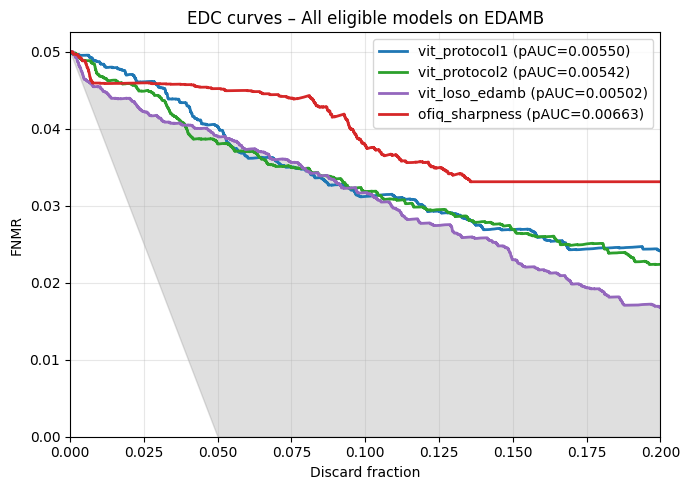

In [145]:

# ============================================================
# Combined EDC plot (ALL models on EDAMB)
# with subtracting theoretical best pAUC value and color coding graphs
# ============================================================

quality_cols = [
    "pred_protocol1",
    "pred_protocol2",
    "pred_loso_edamb",
    "pred_ofiq",
]

LEGEND_NAME_MAP = {
    "pred_protocol1": "vit_protocol1",
    "pred_protocol2": "vit_protocol2",
    "pred_ofiq": "ofiq_sharpness",
    "pred_loso_edamb": "vit_loso_edamb",
}
COLOR_MAP = {
    "vit_protocol1": "tab:blue",
    "vit_protocol2": "tab:green",
   # "vit_loso_gjovik": "tab:orange",
    "vit_loso_edamb": "tab:purple",
    "ofiq_sharpness": "tab:red",
}
def get_legend_name(qc, exp_name=None):
    return LEGEND_NAME_MAP.get(qc, qc)


THEORETICAL_BEST_PAUC = 0.00125

plt.figure(figsize=(7, 5))

pauc_results_raw = {}
pauc_results_corrected = {}
edc_curves = {}

all_y0 = []

for qc in quality_cols:
    tmp = attach_pair_quality(pair_df, sample_df_quality, qc)
    x, y = compute_fnmr_edc(tmp, EXPERIMENT_THRESHOLD)

    pa_raw = pauc_raw(x, y)
    pa_corrected = pa_raw - THEORETICAL_BEST_PAUC

    pauc_results_raw[qc] = pa_raw
    pauc_results_corrected[qc] = pa_corrected
    edc_curves[qc] = (x, y)

    all_y0.append(y[0])

    pretty_name = get_legend_name(qc, exp_name)

    plt.plot(
        x,
        y,
        label=f"{pretty_name} (pAUC={pa_corrected:.5f})",
        linewidth=2,
        color=COLOR_MAP.get(pretty_name, "black"),
        zorder=2
    )

# ============================================================
# Shade area under lowest-pAUC graph, excluding bottom-left triangle
# ============================================================

best_qc = min(pauc_results_raw, key=pauc_results_raw.get)
best_x, best_y = edc_curves[best_qc]

# Only shade inside the plotted discard range
mask = best_x <= 0.2
x_fill = best_x[mask]
y_fill = best_y[mask]

# Lower boundary:
# - diagonal from (0, 0.05) to (0.05, 0)
# - then 0 afterwards
lower_boundary = np.maximum(0.05 - x_fill, 0)

plt.fill_between(
    x_fill,
    lower_boundary,
    y_fill,
    where=y_fill >= lower_boundary,
    interpolate=True,
    color="grey",
    alpha=0.25,
    #label=f"Area above theoretical best: {get_legend_name(best_qc, exp_name)}",
    zorder=1
)

# ============================================================
# Sanity check: FNMR fixed
# ============================================================

assert np.allclose(all_y0, TARGET_FNMR, atol=1e-3)

plt.xlim(0, 0.2)
plt.ylim(bottom=0)
plt.xlabel("Discard fraction")
plt.ylabel("FNMR")
plt.title("EDC curves – All eligible models on EDAMB")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

png_path = EDC_OUT_DIR / "edc_entire_edamb_correct_colours.png"
#pdf_path1 = EDC_OUT_DIR / "fnm_edc_entire_edamb_correctLabelpAU.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
#plt.savefig(pdf_path1, bbox_inches="tight")

plt.show()



### Plot models for ALL protocols at the same time


=== Plotting EDC for experiment: protocol1 ===
Threshold for protocol1 (FNMR=0.05): 0.1239


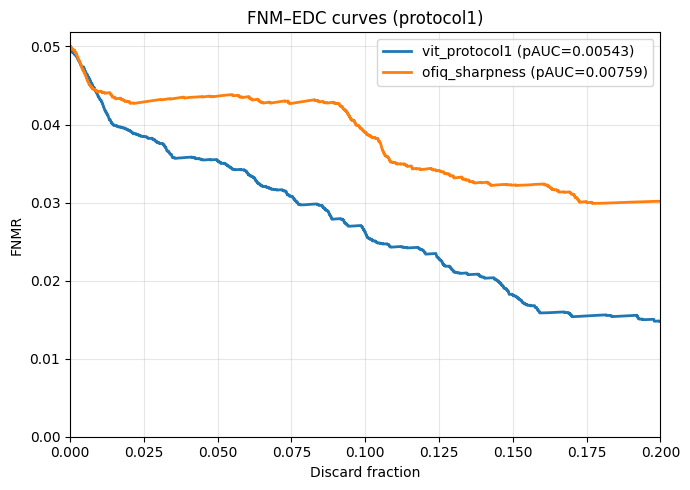

Saved EDC plots to:
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/fnm_edc_protocol1_correctLabel.png
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/fnm_edc_protocol1_correctLabel.pdf

=== Plotting EDC for experiment: protocol2 ===
Threshold for protocol2 (FNMR=0.05): 0.0500


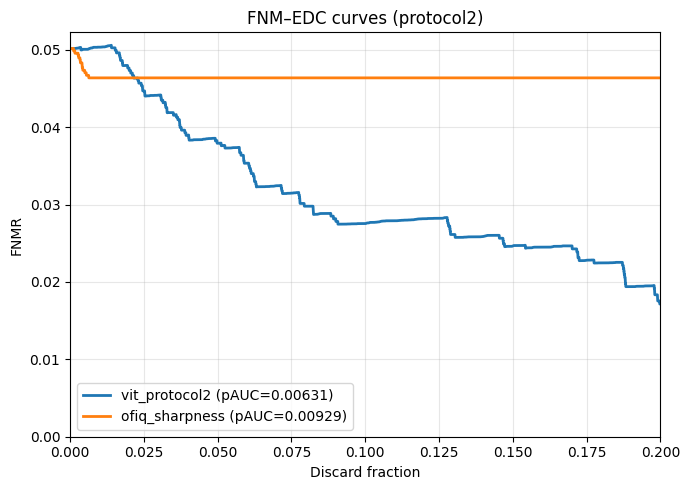

Saved EDC plots to:
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/fnm_edc_protocol2_correctLabel.png
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/fnm_edc_protocol2_correctLabel.pdf

=== Plotting EDC for experiment: loso_custom ===
Threshold for loso_custom (FNMR=0.05): 0.1217


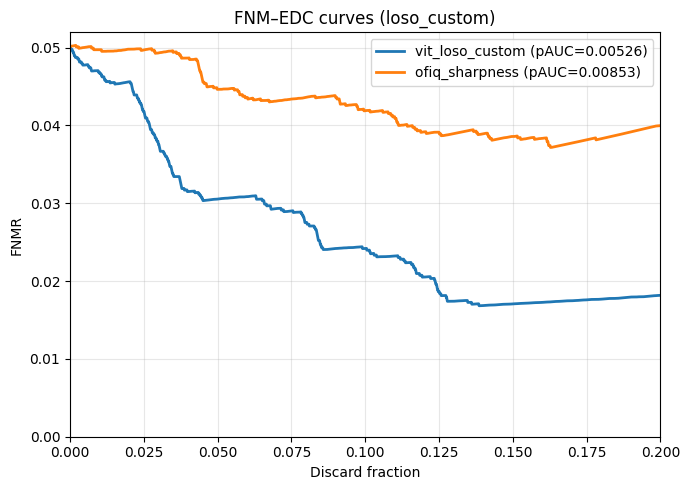

Saved EDC plots to:
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/fnm_edc_loso_custom_correctLabel.png
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/fnm_edc_loso_custom_correctLabel.pdf

=== Plotting EDC for experiment: loso_edamb ===
Threshold for loso_edamb (FNMR=0.05): 0.0801


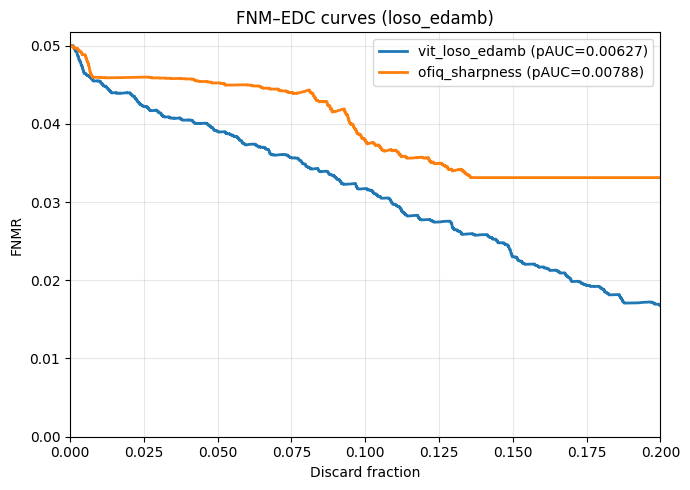

Saved EDC plots to:
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/fnm_edc_loso_edamb_correctLabel.png
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/fnm_edc_loso_edamb_correctLabel.pdf


In [114]:
# ============================================================
# EDC plots for ALL experiment variants (model + OFIQ)
# ============================================================

from pathlib import Path

EDC_OUT_DIR = OUT_DIR / "EDC_plots"
EDC_OUT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_FNMR = 0.05

def threshold_from_mated(pair_df, target_fnmr=0.05):
    genuine_scores = pair_df.loc[
        pair_df["is_mated"] == 1, "comparison_score"
    ].to_numpy()
    return float(np.quantile(genuine_scores, target_fnmr))


quality_cols = ["pred_vit", "pred_ofiq"]

ALL_PAUC_RESULTS = []

for exp_name, exp_cfg in EXPERIMENTS.items():
    print(f"\n=== Plotting EDC for experiment: {exp_name} ===")

    # --------------------------------------------------------
    # Load experiment-specific data
    # --------------------------------------------------------
    sample_df = load_experiment_sample_table(exp_cfg)

    pair_path = OUT_DIR / f"pickle_files/pairs_{exp_name}.pkl"
    if not pair_path.exists():
        print(f"WARNING: pair_df not found for {exp_name}, skipping")
        continue

    pair_df = pd.read_pickle(pair_path)

    # --------------------------------------------------------
    # Threshold calibration (FNMR = 0.05) — ONCE PER EXPERIMENT
    # --------------------------------------------------------
    EXPERIMENT_THRESHOLD = threshold_from_mated(
        pair_df, target_fnmr=TARGET_FNMR
    )
    print(
        f"Threshold for {exp_name} (FNMR={TARGET_FNMR:.2f}): "
        f"{EXPERIMENT_THRESHOLD:.4f}"
    )

    # --------------------------------------------------------
    # Plot EDC curves
    # --------------------------------------------------------

    ############ section to change legend names #####
    LEGEND_NAME_MAP = {
    "pred_ofiq": "ofiq_sharpness",

    "pred_vit": {
        "protocol1": "vit_protocol1",
        "protocol2": "vit_protocol2",
        "loso_custom": "vit_loso_custom",
        "loso_edamb": "vit_loso_edamb",
        },
    }
    def get_legend_name(qc, exp_name):
        mapping = LEGEND_NAME_MAP.get(qc, qc)
    
        # if mapping is a dict → depends on experiment
        if isinstance(mapping, dict):
            return mapping.get(exp_name, qc)
    
        # otherwise fixed name
        return mapping
    ##########################################
    
    plt.figure(figsize=(7, 5))

    all_y0 = []
    pauc_results = {}

    for qc in quality_cols:
        if qc not in sample_df.columns:
            print(f"  Skipping {qc} (not present in sample_df)")
            continue

        tmp = attach_pair_quality(pair_df, sample_df, qc)
        x, y = compute_fnmr_edc(tmp, EXPERIMENT_THRESHOLD)

        pa = pauc_raw(x, y)
        pauc_results[qc] = pa
        all_y0.append(y[0])
        """
        plt.plot(
            x,
            y,
            label=f"{qc} (pAUC={pa:.5f})",
            linewidth=2
        )
        """

        pretty_name = get_legend_name(qc, exp_name)
        plt.plot(
            x,
            y,
            label=f"{pretty_name} (pAUC={pa:.5f})",
            linewidth=2
        )
        
        ALL_PAUC_RESULTS.append({
            "experiment": exp_name,
            "method": qc,
            "pAUC_0_20": pa
        })

    # --------------------------------------------------------
    # Sanity check: FNMR at x=0 must equal target FNMR
    # --------------------------------------------------------
    assert np.allclose(
        all_y0, TARGET_FNMR, atol=1e-3
    ), f"FNMR@0 mismatch in {exp_name}"

    # --------------------------------------------------------
    # Plot formatting
    # --------------------------------------------------------
    plt.xlim(0, 0.2)
    plt.ylim(0, None)
    plt.xlabel("Discard fraction")
    plt.ylabel("FNMR")
    plt.title(f"FNM–EDC curves ({exp_name})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # --------------------------------------------------------
    # Save + display
    # --------------------------------------------------------
    png_path = EDC_OUT_DIR / f"fnm_edc_{exp_name}_correctLabel.png"
    pdf_path = EDC_OUT_DIR / f"fnm_edc_{exp_name}_correctLabel.pdf"

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    print(f"Saved EDC plots to:\n  {png_path}\n  {pdf_path}")

#### correct pAUC marking without theoretical best triangle


=== Plotting EDC for experiment: protocol1 ===
Threshold for protocol1 (FNMR=0.05): 0.1239


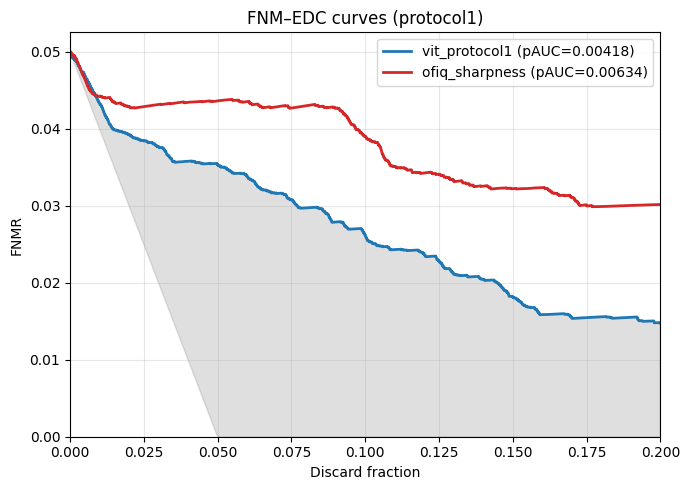

Saved EDC plots to:
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/edc_protocol1_newest.png
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/fnm_edc_loso_edamb_correctLabel.pdf

=== Plotting EDC for experiment: protocol2 ===
Threshold for protocol2 (FNMR=0.05): 0.0500


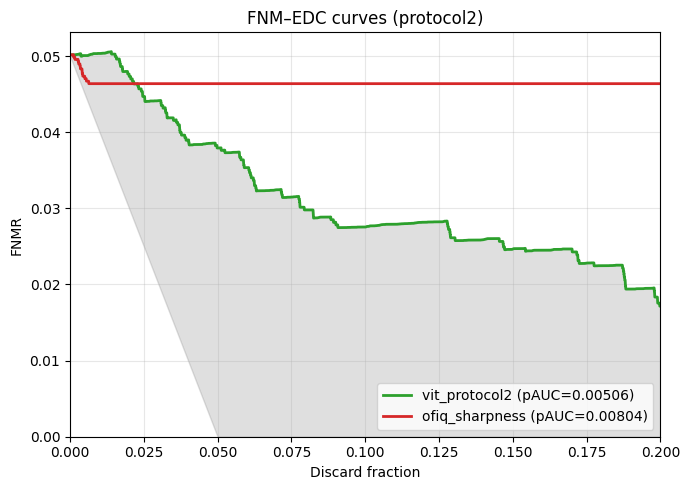

Saved EDC plots to:
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/edc_protocol2_newest.png
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/fnm_edc_loso_edamb_correctLabel.pdf

=== Plotting EDC for experiment: loso_custom ===
Threshold for loso_custom (FNMR=0.05): 0.1217


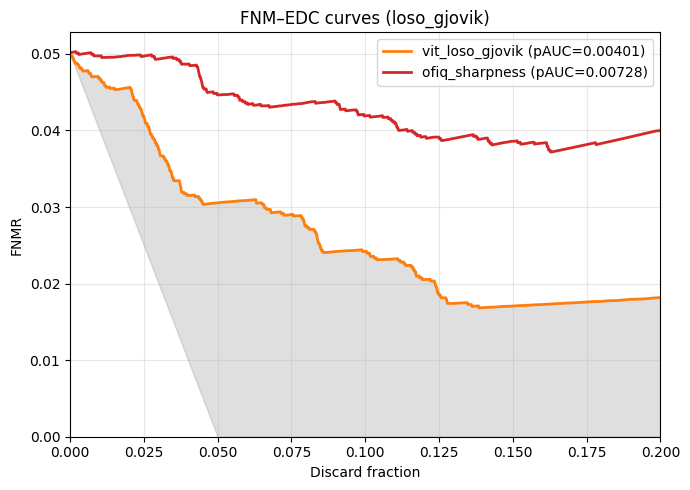

Saved EDC plots to:
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/edc_loso_custom_newest.png
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/fnm_edc_loso_edamb_correctLabel.pdf

=== Plotting EDC for experiment: loso_edamb ===
Threshold for loso_edamb (FNMR=0.05): 0.0801


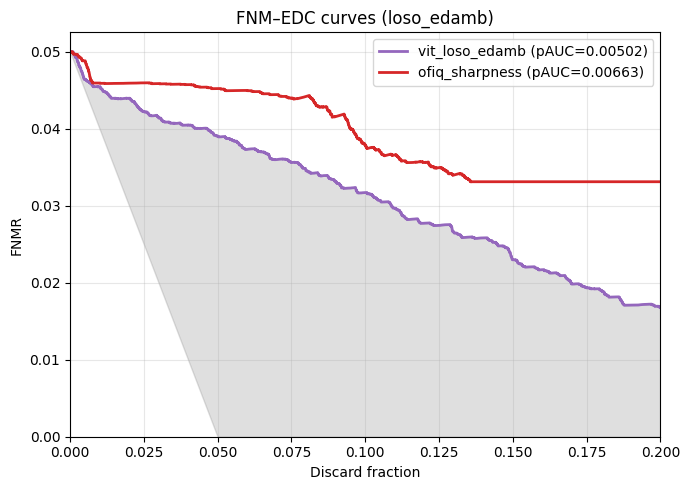

Saved EDC plots to:
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/edc_loso_edamb_newest.png
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/fnm_edc_loso_edamb_correctLabel.pdf


In [142]:
# ============================================================
# EDC plots for ALL experiment variants (model + OFIQ)
# ============================================================

from pathlib import Path

EDC_OUT_DIR = OUT_DIR / "EDC_plots"
EDC_OUT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_FNMR = 0.05

def threshold_from_mated(pair_df, target_fnmr=0.05):
    genuine_scores = pair_df.loc[
        pair_df["is_mated"] == 1, "comparison_score"
    ].to_numpy()
    return float(np.quantile(genuine_scores, target_fnmr))


quality_cols = ["pred_vit", "pred_ofiq"]

ALL_PAUC_RESULTS = []

for exp_name, exp_cfg in EXPERIMENTS.items():
    print(f"\n=== Plotting EDC for experiment: {exp_name} ===")

    # --------------------------------------------------------
    # Load experiment-specific data
    # --------------------------------------------------------
    sample_df = load_experiment_sample_table(exp_cfg)

    pair_path = OUT_DIR / f"pickle_files/pairs_{exp_name}.pkl"
    if not pair_path.exists():
        print(f"WARNING: pair_df not found for {exp_name}, skipping")
        continue

    pair_df = pd.read_pickle(pair_path)

    # --------------------------------------------------------
    # Threshold calibration (FNMR = 0.05) — ONCE PER EXPERIMENT
    # --------------------------------------------------------
    EXPERIMENT_THRESHOLD = threshold_from_mated(
        pair_df, target_fnmr=TARGET_FNMR
    )
    print(
        f"Threshold for {exp_name} (FNMR={TARGET_FNMR:.2f}): "
        f"{EXPERIMENT_THRESHOLD:.4f}"
    )

    # --------------------------------------------------------
    # Plot EDC curves
    # --------------------------------------------------------

    ############ section to change legend names #####
    LEGEND_NAME_MAP = {
    "pred_ofiq": "ofiq_sharpness",

    "pred_vit": {
        "protocol1": "vit_protocol1",
        "protocol2": "vit_protocol2",
        "loso_custom": "vit_loso_gjovik",
        "loso_edamb": "vit_loso_edamb",
        },
    }
    
    COLOR_MAP = {
        "vit_protocol1": "tab:blue",
        "vit_protocol2": "tab:green",
        "vit_loso_gjovik": "tab:orange",
        "vit_loso_edamb": "tab:purple",
        "ofiq_sharpness": "tab:red",
    }


    def get_legend_name(qc, exp_name):
        mapping = LEGEND_NAME_MAP.get(qc, qc)
    
        # if mapping is a dict → depends on experiment
        if isinstance(mapping, dict):
            return mapping.get(exp_name, qc)
    
        # otherwise fixed name
        return mapping
    ##########################################
    
    plt.figure(figsize=(7, 5))

    THEORETICAL_BEST_PAUC = 0.00125
    
    all_y0 = []
    pauc_results_raw = {}
    pauc_results_corrected = {}
    edc_curves = {}
    
    for qc in quality_cols:
        if qc not in sample_df.columns:
            print(f"  Skipping {qc} (not present in sample_df)")
            continue
    
        tmp = attach_pair_quality(pair_df, sample_df, qc)
        x, y = compute_fnmr_edc(tmp, EXPERIMENT_THRESHOLD)
    
        pa_raw = pauc_raw(x, y)
        pa_corrected = pa_raw - THEORETICAL_BEST_PAUC
    
        pauc_results_raw[qc] = pa_raw
        pauc_results_corrected[qc] = pa_corrected
        edc_curves[qc] = (x, y)
    
        all_y0.append(y[0])
    
        pretty_name = get_legend_name(qc, exp_name)
    
        plt.plot(
            x,
            y,
            label=f"{pretty_name} (pAUC={pa_corrected:.5f})",
            linewidth=2,
            color=COLOR_MAP.get(pretty_name, "black"),
            zorder=2
        )
    
        ALL_PAUC_RESULTS.append({
            "experiment": exp_name,
            "method": qc,
            "method_label": pretty_name,
            "pAUC_raw_0_20": pa_raw,
            "pAUC_corrected_0_20": pa_corrected
        })
   
    # --------------------------------------------------------
    # Shade area under the lowest-pAUC curve,
    # excluding the theoretical-best bottom-left triangle
    # --------------------------------------------------------
    
    if len(pauc_results_raw) > 0:
        best_qc = min(pauc_results_raw, key=pauc_results_raw.get)
        best_x, best_y = edc_curves[best_qc]
    
        # Restrict shading to the plotted pAUC range: discard fraction 0–0.2
        mask = best_x <= 0.2
        x_fill = best_x[mask]
        y_fill = best_y[mask]
    
        # Theoretical-best lower boundary:
        # straight line from (0, 0.05) to (0.05, 0),
        # then y = 0 afterwards.
        lower_boundary = np.maximum(TARGET_FNMR - x_fill, 0)
    
        plt.fill_between(
            x_fill,
            lower_boundary,
            y_fill,
            where=y_fill >= lower_boundary,
            interpolate=True,
            color="grey",
            alpha=0.25,
            #label=f"Shaded area: {get_legend_name(best_qc, exp_name)}",
            zorder=1
        )

    # --------------------------------------------------------
    # Sanity check: FNMR at x=0 must equal target FNMR
    # --------------------------------------------------------
    assert np.allclose(
        all_y0, TARGET_FNMR, atol=1e-3
    ), f"FNMR@0 mismatch in {exp_name}"

    # --------------------------------------------------------
    # Plot formatting
    # --------------------------------------------------------
    plt.xlim(0, 0.2)
    plt.ylim(0, None)
    plt.xlabel("Discard fraction")
    plt.ylabel("FNMR")
    if exp_name == "loso_custom":
        plt.title(f"FNM–EDC curves (loso_gjovik)")
    else:
        plt.title(f"FNM–EDC curves ({exp_name})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # --------------------------------------------------------
    # Save + display
    # --------------------------------------------------------
    png_path = EDC_OUT_DIR / f"edc_{exp_name}_newest.png"
    #pdf_path = EDC_OUT_DIR / f"fnm_edc_{exp_name}_correctLabel.pdf"

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    #plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    print(f"Saved EDC plots to:\n  {png_path}\n  {pdf_path}")

#### small testing for illustrative purposes


=== Plotting EDC for experiment: protocol1 ===
Threshold for protocol1 (FNMR=0.05): 0.1239


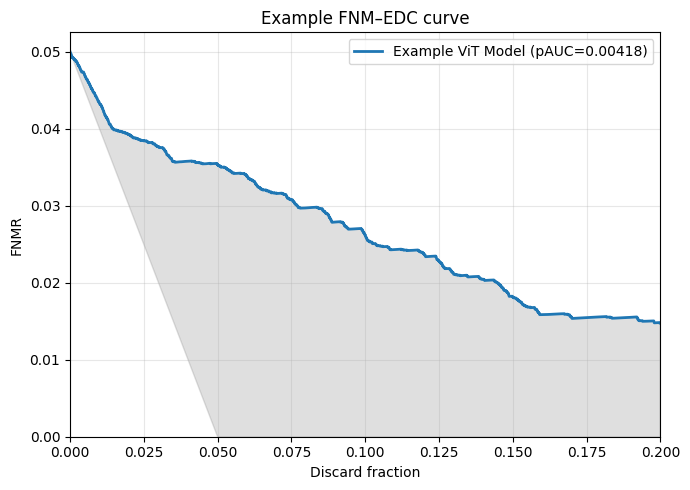

Saved EDC plots to:
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/edc_protocol1_ILLUSTRATION.png
  /margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/fnm_edc_loso_edamb_correctLabel.pdf


In [136]:
#TESTING TESTING TESTING - GENERATE EDC FORR ILLUSTRATIVE PURPOSES


# ============================================================
# EDC plots for ALL experiment variants (model + OFIQ)
# ============================================================

from pathlib import Path

EDC_OUT_DIR = OUT_DIR / "EDC_plots"
EDC_OUT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_FNMR = 0.05

def threshold_from_mated(pair_df, target_fnmr=0.05):
    genuine_scores = pair_df.loc[
        pair_df["is_mated"] == 1, "comparison_score"
    ].to_numpy()
    return float(np.quantile(genuine_scores, target_fnmr))


quality_cols = ["pred_vit"]

ALL_PAUC_RESULTS = []

for exp_name, exp_cfg in EXPERIMENTS.items():
    
    if exp_name != "protocol1":
        continue

    print(f"\n=== Plotting EDC for experiment: {exp_name} ===")

    # --------------------------------------------------------
    # Load experiment-specific data
    # --------------------------------------------------------
    sample_df = load_experiment_sample_table(exp_cfg)

    pair_path = OUT_DIR / f"pickle_files/pairs_{exp_name}.pkl"
    if not pair_path.exists():
        print(f"WARNING: pair_df not found for {exp_name}, skipping")
        continue

    pair_df = pd.read_pickle(pair_path)

    # --------------------------------------------------------
    # Threshold calibration (FNMR = 0.05) — ONCE PER EXPERIMENT
    # --------------------------------------------------------
    EXPERIMENT_THRESHOLD = threshold_from_mated(
        pair_df, target_fnmr=TARGET_FNMR
    )
    print(
        f"Threshold for {exp_name} (FNMR={TARGET_FNMR:.2f}): "
        f"{EXPERIMENT_THRESHOLD:.4f}"
    )

    # --------------------------------------------------------
    # Plot EDC curves
    # --------------------------------------------------------

    ############ section to change legend names #####
    LEGEND_NAME_MAP = {
    "pred_ofiq": "ofiq_sharpness",

    "pred_vit": {
        "protocol1": "Example ViT Model",
        "protocol2": "vit_protocol2",
        "loso_custom": "vit_loso_custom",
        "loso_edamb": "vit_loso_edamb",
        },
    }
    def get_legend_name(qc, exp_name):
        mapping = LEGEND_NAME_MAP.get(qc, qc)
    
        # if mapping is a dict → depends on experiment
        if isinstance(mapping, dict):
            return mapping.get(exp_name, qc)
    
        # otherwise fixed name
        return mapping
    ##########################################
    
    plt.figure(figsize=(7, 5))

    THEORETICAL_BEST_PAUC = 0.00125
    
    all_y0 = []
    pauc_results_raw = {}
    pauc_results_corrected = {}
    edc_curves = {}
    
    for qc in quality_cols:
        if qc not in sample_df.columns:
            print(f"  Skipping {qc} (not present in sample_df)")
            continue
    
        tmp = attach_pair_quality(pair_df, sample_df, qc)
        x, y = compute_fnmr_edc(tmp, EXPERIMENT_THRESHOLD)
    
        pa_raw = pauc_raw(x, y)
        pa_corrected = pa_raw - THEORETICAL_BEST_PAUC
    
        pauc_results_raw[qc] = pa_raw
        pauc_results_corrected[qc] = pa_corrected
        edc_curves[qc] = (x, y)
    
        all_y0.append(y[0])
    
        pretty_name = get_legend_name(qc, exp_name)
    
        plt.plot(
            x,
            y,
            label=f"{pretty_name} (pAUC={pa_corrected:.5f})",
            linewidth=2,
            zorder=2
        )
    
        ALL_PAUC_RESULTS.append({
            "experiment": exp_name,
            "method": qc,
            "method_label": pretty_name,
            "pAUC_raw_0_20": pa_raw,
            "pAUC_corrected_0_20": pa_corrected
        })
   
    # --------------------------------------------------------
    # Shade area under the lowest-pAUC curve,
    # excluding the theoretical-best bottom-left triangle
    # --------------------------------------------------------
    
    if len(pauc_results_raw) > 0:
        best_qc = min(pauc_results_raw, key=pauc_results_raw.get)
        best_x, best_y = edc_curves[best_qc]
    
        # Restrict shading to the plotted pAUC range: discard fraction 0–0.2
        mask = best_x <= 0.2
        x_fill = best_x[mask]
        y_fill = best_y[mask]
    
        # Theoretical-best lower boundary:
        # straight line from (0, 0.05) to (0.05, 0),
        # then y = 0 afterwards.
        lower_boundary = np.maximum(TARGET_FNMR - x_fill, 0)
    
        plt.fill_between(
            x_fill,
            lower_boundary,
            y_fill,
            where=y_fill >= lower_boundary,
            interpolate=True,
            color="grey",
            alpha=0.25,
            #label=f"Shaded area: {get_legend_name(best_qc, exp_name)}",
            zorder=1
        )

    # --------------------------------------------------------
    # Sanity check: FNMR at x=0 must equal target FNMR
    # --------------------------------------------------------
    assert np.allclose(
        all_y0, TARGET_FNMR, atol=1e-3
    ), f"FNMR@0 mismatch in {exp_name}"

    # --------------------------------------------------------
    # Plot formatting
    # --------------------------------------------------------
    plt.xlim(0, 0.2)
    plt.ylim(0, None)
    plt.xlabel("Discard fraction")
    plt.ylabel("FNMR")
    plt.title(f"Example FNM–EDC curve")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # --------------------------------------------------------
    # Save + display
    # --------------------------------------------------------
    png_path = EDC_OUT_DIR / f"edc_{exp_name}_ILLUSTRATION.png"
    #pdf_path = EDC_OUT_DIR / f"fnm_edc_{exp_name}_correctLabel.pdf"

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    #plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    print(f"Saved EDC plots to:\n  {png_path}\n  {pdf_path}")

#### testing above done

In [69]:
# ============================================================
# Aggregate pAUC across experiments
# ============================================================

ALL_RESULTS = []

for exp_name, exp_cfg in EXPERIMENTS.items():
    print(f"Evaluating {exp_name}")

        # I've previously saved all the mated pairs in a file that's fetched beolw
    sample_df = load_experiment_sample_table(exp_cfg)
    pair_df = pd.read_pickle(OUT_DIR / f"pickle_files/pairs_{exp_name}.pkl")

    # Threshold calibrated on THIS experiment's mated pairs
    threshold = threshold_from_mated(pair_df, target_fnmr=0.05)

    for qc in ["pred_vit", "pred_ofiq"]:
        tmp = attach_pair_quality(pair_df, sample_df, qc)
        x, y = compute_fnmr_edc(tmp, threshold)
        pa = pauc_raw(x, y)

        ALL_RESULTS.append({
            "experiment": exp_name,
            "method": qc,
            "pAUC_0_20": pa
        })

pauc_df = pd.DataFrame(ALL_RESULTS)
display(pauc_df)
pauc_df.to_csv("/margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/pAUC.csv")

Evaluating protocol1
Evaluating protocol2
Evaluating loso_custom
Evaluating loso_edamb


,experiment,method,pAUC_0_20
0,protocol1,pred_vit,0.005430
1,protocol1,pred_ofiq,0.007587
2,protocol2,pred_vit,0.006309
3,protocol2,pred_ofiq,0.009289
4,loso_custom,pred_vit,0.005263
5,loso_custom,pred_ofiq,0.008527
6,loso_edamb,pred_vit,0.006271
7,loso_edamb,pred_ofiq,0.007880


#### Created for building curves for models ALL tested on whole EDAMB

In [76]:
# ============================================================
# pAUC summary table
# ============================================================

pauc_table = pd.DataFrame([
    {
        "method": k,
        "pAUC": v,
        "delta_pAUC_vs_OFIQ": pauc_results["pred_ofiq"] - v
    }
    for k, v in pauc_results.items()
])

pauc_table = pauc_table.sort_values("delta_pAUC_vs_OFIQ", ascending=False)

display(pauc_table)

pauc_table.to_csv(OUT_DIR / "pauc_all_models_edamb.csv", index=False)
pauc_table.to_latex(
    OUT_DIR / "pauc_all_models_edamb.tex",
    index=False,
    float_format="%.5f"
)

,method,pAUC,delta_pAUC_vs_OFIQ
2,pred_loso_edamb,0.006271,0.001609
1,pred_protocol2,0.006666,0.001214
0,pred_protocol1,0.006751,0.001129
3,pred_ofiq,0.007880,0.000000


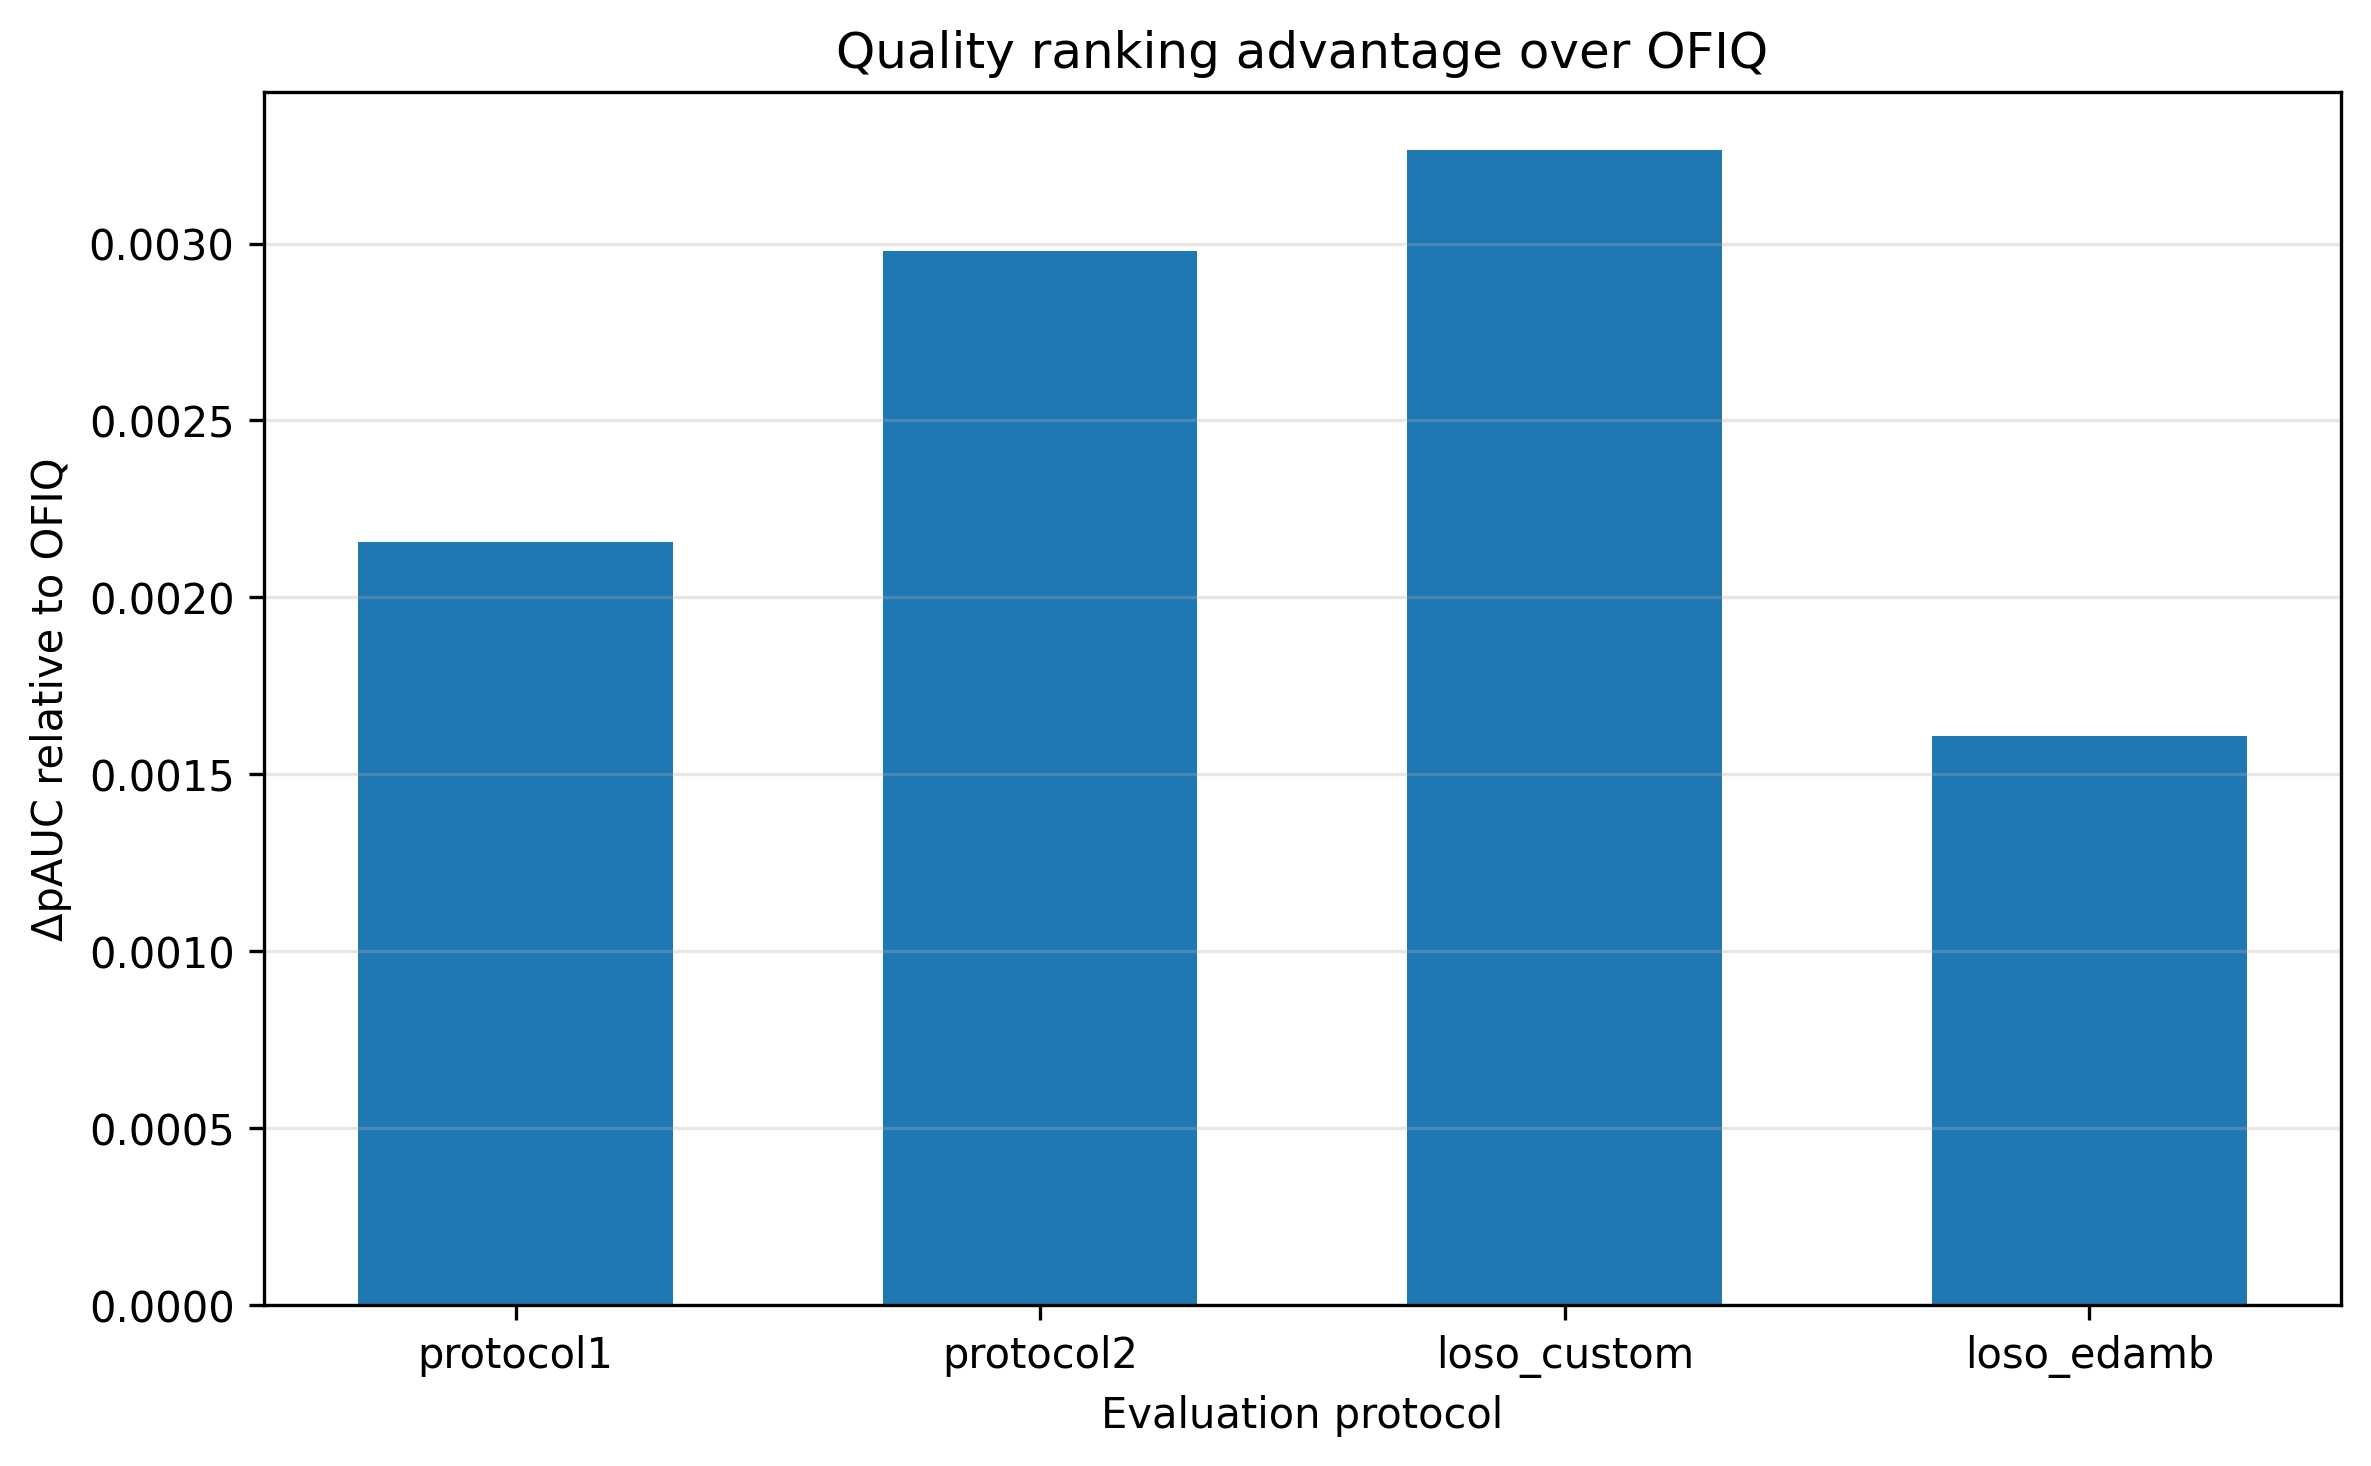

In [86]:
# fetch a saved image
from IPython.display import Image, display
img = "/margrethe/code/models/00_FINAL_REPORTING/EDC_pAUC/main_reporting/EDC_plots/delta_pAUC_over_OFIQ.png"
display(Image(filename=img))

## more FNMR, pAUC calaulatios

In [81]:
# ============================================================
# Build FNMR₀ + pAUC summary table 
# helps answer/study how FIQA gains vary when baseline recognition performance is worse (FNMR higher)
# ============================================================

TARGET_FNMR = 0.05

def threshold_from_mated(pair_df, target_fnmr=0.05):
    genuine_scores = pair_df.loc[
        pair_df["is_mated"] == 1, "comparison_score"
    ].to_numpy()
    return float(np.quantile(genuine_scores, target_fnmr))


SUMMARY_ROWS = []

for exp_name, exp_cfg in EXPERIMENTS.items():
    print(f"Processing experiment: {exp_name}")

    # --------------------------------------------------------
    # Load data
    # --------------------------------------------------------
    sample_df = load_experiment_sample_table(exp_cfg)
    pair_path = OUT_DIR / f"pickle_files/pairs_{exp_name}.pkl"

    if not pair_path.exists():
        print(f"  Skipping {exp_name} (pairs not found)")
        continue

    pair_df = pd.read_pickle(pair_path)

    # --------------------------------------------------------
    # Calibrate threshold (FNMR = 0.05)
    # --------------------------------------------------------
    threshold = threshold_from_mated(pair_df, TARGET_FNMR)

    # --------------------------------------------------------
    # Compute EDC curves for model and OFIQ
    # --------------------------------------------------------
    results = {}

    for qc in ["pred_vit", "pred_ofiq"]:
        if qc not in sample_df.columns:
            continue

        tmp = attach_pair_quality(pair_df, sample_df, qc)
        x, y = compute_fnmr_edc(tmp, threshold)

        results[qc] = {
            "FNMR0": y[0],
            "pAUC": pauc_raw(x, y)
        }

    # --------------------------------------------------------
    # Sanity check: baseline FNMR must be identical
    # --------------------------------------------------------
    assert abs(
        results["pred_vit"]["FNMR0"] - TARGET_FNMR
    ) < 1e-3, f"FNMR0 mismatch in {exp_name}"

    # --------------------------------------------------------
    # Store summary row
    # --------------------------------------------------------
    pauc_model = results["pred_vit"]["pAUC"]
    pauc_ofiq = results["pred_ofiq"]["pAUC"]

    SUMMARY_ROWS.append({
        "experiment": exp_name,
        "FNMR0": results["pred_vit"]["FNMR0"],
        "pAUC_model": pauc_model,
        "pAUC_ofiq": pauc_ofiq,
        "delta_pAUC_abs": pauc_ofiq - pauc_model,
    })


# ------------------------------------------------------------
# Build dataframe
# ------------------------------------------------------------
summary_df = pd.DataFrame(SUMMARY_ROWS)

display(summary_df)

# Optional: save for later analysis
summary_df.to_csv(OUT_DIR / "fiqa_fnmr0_pauc_summary.csv", index=False)
summary_df.to_latex(
    OUT_DIR / "fiqa_fnmr0_pauc_summary.tex",
    index=False,
    float_format="%.5f"
)

Processing experiment: protocol1
Processing experiment: protocol2
Processing experiment: loso_custom
Processing experiment: loso_edamb


,experiment,FNMR0,pAUC_model,pAUC_ofiq,delta_pAUC_abs
0,protocol1,0.050045,0.005430,0.007587,0.002157
1,protocol2,0.050136,0.006309,0.009289,0.002980
2,loso_custom,0.050153,0.005263,0.008527,0.003264
3,loso_edamb,0.050015,0.006271,0.007880,0.001609


FNMR0: How often the face recognition system fails before any images are discarded by quality. “If I do NOT use image quality at all, how hard is this recognition problem?”\
delta_pAUC_abs:"How much better MY model is than OFIQ at ranking samples for discard" "Given the same recognition system and operating point, does my model discard the right images better than OFIQ?” I know it does tho :D It is the area between the EDC curves. 

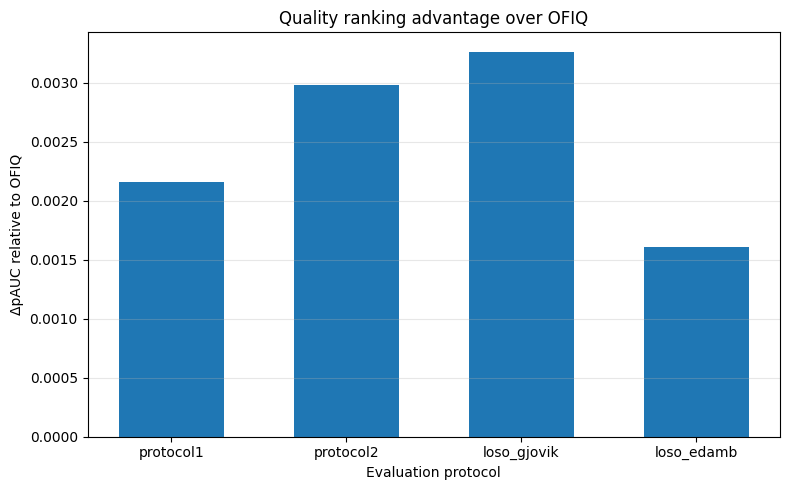

In [148]:
summary_df["experiment"] = summary_df["experiment"].replace({
    "loso_custom": "loso_gjovik"
})

plt.figure(figsize=(8, 5))

plt.bar(
    summary_df["experiment"],
    summary_df["delta_pAUC_abs"],
    width=0.6
)

plt.ylabel("ΔpAUC relative to OFIQ")
plt.xlabel("Evaluation protocol")
plt.title("Quality ranking advantage over OFIQ")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()


png_path = EDC_OUT_DIR / f"delta_pAUC_over_OFIQ_newest.png"
pdf_path = EDC_OUT_DIR / f"delta_pAUC_over_OFIQ.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
#plt.savefig(pdf_path, bbox_inches="tight")

plt.show()
